<a href="https://colab.research.google.com/github/IlianRodriguez/Topicos-especiales-II/blob/main/Laboratorios/Laboratorio3/Laboratorio3_IlianRodriguez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1.	Cargue ambos archivos desde la plataforme Moodle**

In [142]:
import pandas as pd#importar libreria pandas
import re
import numpy as np
import matplotlib.pyplot as plt
#URL de los csv en GitHub
urlVentas = "https://raw.githubusercontent.com/IlianRodriguez/Topicos-especiales-II/main/Laboratorios/Laboratorio3/Invoice.csv"
urlClientes = "https://raw.githubusercontent.com/IlianRodriguez/Topicos-especiales-II/main/Laboratorios/Laboratorio3/Customer.csv"

ventas = pd.read_csv(urlVentas, encoding="utf-8")#UTF-8: lee correctamente caracteres especiales como tildes y ñ.
clientes = pd.read_csv(urlClientes, encoding="utf-8")

# **2.	Verificar nulos y duplicados en las dos tablas.**

---

**1. Nulos**

---


In [143]:
print("---------- (Cantidad y porcentaje de nulos en la tabla ventas) ----------")
NulosVentas = ventas.isna().sum()
cantidadNulosVentas = NulosVentas[NulosVentas > 0]

display(pd.DataFrame({
    "Cantidad": cantidadNulosVentas,
    "Porcentaje (%)": (cantidadNulosVentas / len(ventas) * 100).round(2)
}).sort_values("Porcentaje (%)", ascending=False))

print("\n---------- (Cantidad y porcentaje de nulos en la tabla clientes) ----------")
NulosClientes = clientes.isna().sum()
cantidadNulosClientes = NulosClientes[NulosClientes > 0]

display(pd.DataFrame({
    "Cantidad": cantidadNulosClientes,
    "Porcentaje (%)": (cantidadNulosClientes / len(clientes) * 100).round(2)
}).sort_values("Porcentaje (%)", ascending=False))

---------- (Cantidad y porcentaje de nulos en la tabla ventas) ----------


,Cantidad,Porcentaje (%)
BillingState,202,49.03
BillingPostalCode,28,6.80



---------- (Cantidad y porcentaje de nulos en la tabla clientes) ----------


,Cantidad,Porcentaje (%)
Company,49,83.05
Fax,47,79.66
State,29,49.15
PostalCode,4,6.78
Phone,1,1.69


**Tabla ventas**

* **Hallazgos**  
  1. BillingState presenta 202 valores nulos (49.03%) Alto.  
  2. BillingPostalCode presenta 28 valores nulos (6.80%) Medio.  

* **Método de comprobación**  
  1. Se utilizó isna().sum() para identificar y contar los valores nulos por columna.
  2. Se calculó el porcentaje de valores faltantes respecto al total de ventas.

* **Decisiones**  
  4. Reemplazar los valores nulos de la columna BillingPostalCode por su respectivo codigo postal con respecto a BillingAddress.
  5. Reemplazar los valores nulos de la columna BillingState por su respectivo estado con respecto a BillingCity.

**Tabla clientes**

* **Hallazgos**  
  1. Company presenta 49 valores nulos (83.05%) Alto  
  2. Fax presenta 47 valores nulos (79.66%) Alto
  3. State presenta 29 valores nulos (49.15%) Alto   
  4. PostalCode presenta 4 valores nulos(6.78%) Medio
  5. Phone presenta 1 valor nulo (1.69%) Bajo

* **Método de comprobación**  
  1. Se utilizó isna().sum() para contar los valores nulos de cada columna.
  2. Se calculó el porcentaje de valores faltantes con respecto al total de los clientes.  

* **Decisiones**
  1. Eliminar la columna SupportRepId.
  2. Reemplazar los valores nulos de la columna Company por "Sin compañia".
  3. Reemplazar los valores nulos de la columna Fax por "No registrado".
  4. Reemplazar los valores nulos de la columna PostalCode por su respectivo codigo postal con respecto a Address.
  5. Reemplazar los valores nulos de la columna State por su respectivo estado con respecto a City.
  6. Reemplazar los valores nulos de la columna Phone por "No registrado".

In [144]:
#Eliminar columna SupportRepId
clientes = clientes.drop(columns=["SupportRepId"])

#Tabla clientes
clientes["Company"] = clientes["Company"].fillna("Sin compañia")
clientes["Fax"] = clientes["Fax"].fillna("No registrado")
clientes["Phone"] = clientes["Phone"].fillna("No registrado")

#Codigos postales
ventas.loc[ventas["BillingAddress"] == "Rua da Assunção 53", "BillingPostalCode"] = "1100-042"
clientes.loc[clientes["Address"] == "Rua da Assunção 53", "PostalCode"] = "1100-042"

ventas.loc[ventas["BillingAddress"] == "Rua dos Campeões Europeus de Viena, 4350", "BillingPostalCode"] = "4350-414"
clientes.loc[clientes["Address"] == "Rua dos Campeões Europeus de Viena, 4350", "PostalCode"] = "4350-414"

ventas.loc[ventas["BillingAddress"] == "3 Chatham Street", "BillingPostalCode"] = "D02 A529"
clientes.loc[clientes["Address"] == "3 Chatham Street", "PostalCode"] = "D02 A529"

ventas.loc[ventas["BillingAddress"] == "Calle Lira, 198", "BillingPostalCode"] = "8320000"
clientes.loc[clientes["Address"] == "Calle Lira, 198", "PostalCode"] = "8320000"

#Ciudades sin estados
clientes["State"] = clientes["State"].fillna("No aplica")
ventas["BillingState"] = ventas["BillingState"].fillna("No aplica")

#Ciudades faltantes
# Stuttgart
clientes.loc[clientes["City"] == "Stuttgart", "State"] = "BW"
ventas.loc[ventas["BillingCity"] == "Stuttgart", "BillingState"] = "BW"

# Oslo
clientes.loc[clientes["City"] == "Oslo", "State"] = "OS"
ventas.loc[ventas["BillingCity"] == "Oslo", "BillingState"] = "OS"

# Prague
clientes.loc[clientes["City"] == "Prague", "State"] = "PR"
ventas.loc[ventas["BillingCity"] == "Prague", "BillingState"] = "PR"

# Vienne
clientes.loc[clientes["City"] == "Vienne", "State"] = "VI"
ventas.loc[ventas["BillingCity"] == "Vienne", "BillingState"] = "VI"

# Berlin
clientes.loc[clientes["City"] == "Berlin", "State"] = "BE"
ventas.loc[ventas["BillingCity"] == "Berlin", "BillingState"] = "BE"

# Frankfurt
clientes.loc[clientes["City"] == "Frankfurt", "State"] = "HE"
ventas.loc[ventas["BillingCity"] == "Frankfurt", "BillingState"] = "HE"

# Helsinki
clientes.loc[clientes["City"] == "Helsinki", "State"] = "UU"
ventas.loc[ventas["BillingCity"] == "Helsinki", "BillingState"] = "UU"

# Budapest
clientes.loc[clientes["City"] == "Budapest", "State"] = "BU"
ventas.loc[ventas["BillingCity"] == "Budapest", "BillingState"] = "BU"

# Delhi
clientes.loc[clientes["City"] == "Delhi", "State"] = "DE"
ventas.loc[ventas["BillingCity"] == "Delhi", "BillingState"] = "DE"

# Bangalore
clientes.loc[clientes["City"] == "Bangalore", "State"] = "KA"
ventas.loc[ventas["BillingCity"] == "Bangalore", "BillingState"] = "KA"

In [145]:
#Comprovacion final de valores nulos
print("---------- (Cantidad y porcentaje de nulos en la tabla ventas) ----------")
NulosVentas = ventas.isna().sum()
cantidadNulosVentas = NulosVentas[NulosVentas > 0]

display(pd.DataFrame({
    "Cantidad": cantidadNulosVentas,
    "Porcentaje (%)": (cantidadNulosVentas / len(ventas) * 100).round(2)
}).sort_values("Porcentaje (%)", ascending=False))

print("\n---------- (Cantidad y porcentaje de nulos en la tabla clientes) ----------")
NulosClientes = clientes.isna().sum()
cantidadNulosClientes = NulosClientes[NulosClientes > 0]

display(pd.DataFrame({
    "Cantidad": cantidadNulosClientes,
    "Porcentaje (%)": (cantidadNulosClientes / len(clientes) * 100).round(2)
}).sort_values("Porcentaje (%)", ascending=False))

---------- (Cantidad y porcentaje de nulos en la tabla ventas) ----------


,Cantidad,Porcentaje (%)



---------- (Cantidad y porcentaje de nulos en la tabla clientes) ----------


,Cantidad,Porcentaje (%)


---

**2. Duplicados**

---

In [146]:
print("---------- Ventas ----------")
print("Exactamente duplicadas:", ventas.duplicated().sum())
print("InvoiceId duplicados:", ventas["InvoiceId"].duplicated().sum())

print("\n---------- Clientes ----------")
print("Exactamente duplicadas:", clientes.duplicated().sum())
print("CustomerId duplicados:", clientes["CustomerId"].duplicated().sum())

---------- Ventas ----------
Exactamente duplicadas: 0
InvoiceId duplicados: 0

---------- Clientes ----------
Exactamente duplicadas: 0
CustomerId duplicados: 0


**Hallazgos**
1. No se encontraron duplicados exactos en las ventas.
2. No se encontraron duplicados exactos en los clientes.
3. No se encontraron `InvoiceId` duplicados en las ventas.
4. No se encontraron `CustomerId` duplicados en los clientes.    
  
**Método de comprobación**
1. Se uso `duplicated()` para verificar los duplicados exactos
2. Se uso `duplicated()` sobre las columnas `InvoiceId` y `CustomerId` para comprobar si existían registros repetidos por identificador.

**Decisiones**
1. No fue necesario eliminar ningún registro, ya que no se encontraron duplicados exactos ni duplicados en los identificadores principales de cada DataFrame.


---

**3. Inconsistencias**

---



In [147]:
print("---------- Numeros de telefono de clientes ----------")
display(clientes["Phone"].head(5))

---------- Numeros de telefono de clientes ----------


,Phone
0,+55 (12) 3923-5555
1,+49 0711 2842222
2,+1 (514) 721-4711
3,+47 22 44 22 22
4,+420 2 4172 5555


**Hallazgos**
1. Los números pertenecen a diferentes países, por lo que no todos tienen la misma cantidad de dígitos ni la misma estructura.
2. Se encontraron números telefónicos almacenados con diferentes formatos, utilizando espacios, paréntesis, el símbolo `+` y guiones.

**Método de comprobación**
1. Se revisaron los valores de la columna `Phone` para identificar diferencias en la forma en que estaban escritos.
2. Se compararon los diferentes formatos utilizados en los números telefónicos, identificando los caracteres que podían estandarizarse sin modificar los números.

**Decisiones**
1. Se estandarizó la columna `Phone` eliminando los símbolos `+`, `(` y `)`, y reemplazando los espacios por guiones `-`, manteniendo los números originales.


In [148]:
def limpiarTelefono(valor):
    if pd.isna(valor):
        return np.nan

    valor = re.sub(r"[+()]", "", str(valor))
    valor = valor.replace(" ", "-")

    return valor

clientes["Phone"] = clientes["Phone"].apply(limpiarTelefono)

In [149]:
print("---------- Numeros de telefono de clientes ----------")
display(clientes["Phone"].head(5))

---------- Numeros de telefono de clientes ----------


,Phone
0,55-12-3923-5555
1,49-0711-2842222
2,1-514-721-4711
3,47-22-44-22-22
4,420-2-4172-5555


In [150]:
print("---------- direcciones de clientes ----------")
display(clientes["Address"].head(5))

print("---------- direcciones de ventas ----------")
display(ventas["BillingAddress"].head(5))

---------- direcciones de clientes ----------


,Address
0,"Av. Brigadeiro Faria Lima, 2170"
1,Theodor-Heuss-Straße 34
2,1498 rue Bélanger
3,Ullevålsveien 14
4,Klanova 9/506


---------- direcciones de ventas ----------


,BillingAddress
0,Theodor-Heuss-Straße 34
1,Ullevålsveien 14
2,Grétrystraat 63
3,8210 111 ST NW
4,69 Salem Street


**Hallazgos**
1. Las direcciones tenían diferentes formatos.
2. Algunas usaban el número al inicio y otras al final.

**Método de comprobación**
1. Se revisaron las columnas Address y BillingAddress.
2. Se identificaron los formatos que podían unificarse.

**Decisiones**
1. Se estandarizaron las direcciones al formato `número, texto` cuando fue posible.


In [151]:
def estandarizarDireccion(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip()

    # Número al inicio
    if re.match(r"^\d", valor):
        partes = re.match(r"^(\d+[A-Za-z]?)\s+(.+)$", valor)

        if partes:
            return f"{partes.group(1)}, {partes.group(2)}"

    # Número después de una coma
    partes = re.match(r"^(.+),\s*(\d+[A-Za-z]?)$", valor)

    if partes:
        return f"{partes.group(2)}, {partes.group(1)}"

    # Número al final, separado por espacio o punto
    partes = re.match(r"^(.+?)\s+(\d+[A-Za-z]?)\.?$", valor)

    if partes:
        return f"{partes.group(2)}, {partes.group(1)}"

    return valor

clientes["Address"] = clientes["Address"].apply(estandarizarDireccion)

In [152]:
ventas["BillingAddress"] = ventas["BillingAddress"].apply(estandarizarDireccion)

In [153]:
print("---------- direcciones de clientes ----------")
display(clientes["Address"].head(5))

print("---------- direcciones de ventas ----------")
display(ventas["BillingAddress"].head(5))

---------- direcciones de clientes ----------


,Address
0,"2170, Av. Brigadeiro Faria Lima"
1,"34, Theodor-Heuss-Straße"
2,"1498, rue Bélanger"
3,"14, Ullevålsveien"
4,Klanova 9/506


---------- direcciones de ventas ----------


,BillingAddress
0,"34, Theodor-Heuss-Straße"
1,"14, Ullevålsveien"
2,"63, Grétrystraat"
3,"8210, 111 ST NW"
4,"69, Salem Street"


# **3.	Revisar los tipos de dato**

In [154]:
print("---------- (Tipos de datos de ventas) ----------")
display(ventas.dtypes)

print("\n---------- (Tipos de datos de clientes) ----------")
display(clientes.dtypes)

---------- (Tipos de datos de ventas) ----------


,0
InvoiceId,int64
CustomerId,int64
InvoiceDate,object
BillingAddress,object
BillingCity,object
BillingState,object
BillingCountry,object
BillingPostalCode,object
Total,float64



---------- (Tipos de datos de clientes) ----------


,0
CustomerId,int64
FirstName,object
LastName,object
Company,object
Address,object
City,object
State,object
Country,object
PostalCode,object
Phone,object


* **Hallazgos**
  1. La columna InvoiceDate se cargó como texto (object) y no como fecha.
* **Método de comprobación**
  1. Se revisaron los tipos de datos del DataFrame ventas utilizando ventas.dtypes.
Se verificó que InvoiceDate tenía el tipo object.
* **Decisiones**
  1. Convertir la columna InvoiceDate a formato de fecha utilizando pd.to_datetime() para poder trabajar correctamente con las fechas.

In [155]:
print("---------- (Conversión de InvoiceDate) ----------")
ventas["InvoiceDate"] = pd.to_datetime(ventas["InvoiceDate"])
print(ventas["InvoiceDate"].dtype)

---------- (Conversión de InvoiceDate) ----------
datetime64[ns]


# **4. ¿Cuáles son los 10 países (BillingCountry) que más ingresos generan?**

In [156]:
print("---------- (10 países con mayores ingresos) ----------")
#Top 10 paises que generan mayores ingresos
tbTop10PaisesIngresos = ventas.pivot_table(
    index="BillingCountry",
    values="Total",
    aggfunc="sum"
)
tbTop10PaisesIngresos = tbTop10PaisesIngresos.sort_values("Total", ascending=False)
display(tbTop10PaisesIngresos.head(10))

#Calculo del porcentaje de ventas del primer pais
porcentajePrimerPais = tbTop10PaisesIngresos.iloc[0]["Total"] / ventas["Total"].sum() * 100

print("País con mayores ingresos:", tbTop10PaisesIngresos.index[0])
print("Porcentaje del total:", round(porcentajePrimerPais, 2), "%")

---------- (10 países con mayores ingresos) ----------


,Total
BillingCountry,
USA,523.06
Canada,303.96
France,195.10
Brazil,190.10
Germany,156.48
United Kingdom,112.86
Czech Republic,90.24
Portugal,77.24
India,75.26


País con mayores ingresos: USA
Porcentaje del total: 22.46 %


* **Hallazgos**  
  1. Los 10 países con mayores ingresos fueron identificados y ordenados de mayor a menor.
  2. Estados Unidos (USA) es el país que genera mayores ingresos, con 523.06 que representa el 22.46 % del total de ingresos.

* **Método de comprobación**  
  1. Se utilizó una tabla pivote con BillingCountry y la suma de Total.
  2. Se ordenaron los ingresos de forma descendente y se seleccionaron los primeros 10 países.
  3. Se calculó el porcentaje de USA respecto al total de ingresos.

# **5. Ticket promedio global**

In [157]:
print("---------- (Ticket promedio) ----------")

tbTicketPromedio = ventas.pivot_table(
    index="BillingCountry",
    values="Total",
    aggfunc="mean"
)

ticketPromedioGlobal = ventas["Total"].mean()
print("Ticket promedio global:", round(ticketPromedioGlobal, 2))

display(tbTicketPromedio.loc[["USA", "France"]].round(2))

---------- (Ticket promedio) ----------
Ticket promedio global: 5.65


,Total
BillingCountry,
USA,5.75
France,5.57


* **Hallazgos**
  1. El ticket promedio global fue de 5.65.
  2. Estados Unidos tuvo un ticket promedio de 5.75, mientras que Francia tuvo un ticket promedio de 5.57.
  3. Estados Unidos presentó un ticket promedio ligeramente mayor que Francia.
* **Método de comprobación**
  1. Se utilizó una tabla pivote agrupada por BillingCountry y se aplicó mean sobre la columna Total.
  2. Se obtuvieron los valores correspondientes a USA y France.
  3. Se calculó el ticket promedio global utilizando todas las ventas de la columna Total.

# **6. Tabla: Ingresos totales, número de facturas, y ticket promedio por pais**

In [158]:
print("---------- (Resumen de ventas por país) ----------")

tbResumenPaises = ventas.groupby("BillingCountry").agg(
    Ingresos_Totales=("Total", "sum"),
    Numero_Facturas=("InvoiceId", "count"),
    Ticket_Promedio=("Total", "mean")
)

display(tbResumenPaises)

---------- (Resumen de ventas por país) ----------


,Ingresos_Totales,Numero_Facturas,Ticket_Promedio
BillingCountry,,,
Argentina,37.62,7,5.374286
Australia,37.62,7,5.374286
Austria,42.62,7,6.088571
Belgium,37.62,7,5.374286
Brazil,190.10,35,5.431429
Canada,303.96,56,5.427857
Chile,46.62,7,6.660000
Czech Republic,90.24,14,6.445714
Denmark,37.62,7,5.374286


* **Hallazgos**
  1. Se obtuvo una tabla con los ingresos totales, número de facturas y ticket promedio para cada país.
  2. Los ingresos totales se calcularon a partir de la columna Total.
  3. El número de facturas se obtuvo mediante InvoiceId y el ticket promedio mediante el promedio de Total.  

* **Método de comprobación**
  1. Se utilizó groupby() junto con .agg() para agrupar la información por país y aplicar sum, count y mean a las columnas correspondientes.
  2. Se asignaron nombres a las columnas resultantes para facilitar la interpretación de la tabla.

# **7. merge de las dos tablas y verifique: ¿hay algún caso donde el país del cliente no coincide con el país de la factura**

In [159]:
print("---------- (Comparación de países) ----------")

paisFacturaCliente = ventas.merge(clientes, on="CustomerId", how="inner")
paisFacturaCliente = paisFacturaCliente[paisFacturaCliente["BillingCountry"] != paisFacturaCliente["Country"]]

if paisFacturaCliente.empty:
    print("Resultado: No hay casos donde el país del cliente sea diferente al país de la factura")
else:
    display(paisFacturaCliente[["InvoiceId", "BillingCountry", "CustomerId", "Country"]])

---------- (Comparación de países) ----------
Resultado: No hay casos donde el país del cliente sea diferente al país de la factura


* **Hallazgos**
  1. No se encontraron casos donde el país del cliente sea diferente al país registrado en la factura.

* **Método de comprobación**
  1. Se realizó un merge entre los DataFrames ventas y clientes utilizando CustomerId como clave.
  2. Se utilizó inner porque el objetivo era comparar los datos de clientes que tienen una factura relacionada, evitando incluir registros que no tuvieran correspondencia en ambas tablas.

# **8. ¿Hay algún cliente en Customer que nunca haya generado una factura?**

In [160]:
print("---------- (Clientes sin facturas) ----------")

clientesSinFactura = clientes.merge(ventas,on="CustomerId",how="left")
clientesSinFactura = clientesSinFactura[clientesSinFactura["InvoiceId"].isnull()]

if clientesSinFactura.empty:
    print("Resultado: Todos los clientes han generado al menos una factura")
else:
    display(clientesSinFactura[["InvoiceId", "CustomerId", "FirstName", "LastName"]])

---------- (Clientes sin facturas) ----------
Resultado: Todos los clientes han generado al menos una factura


* **Hallazgos**
  1. No se encontraron clientes que nunca hayan generado una factura.
  2. Todos los clientes registrados en clientes tienen al menos una factura asociada en ventas.
* **Método de comprobación**
  1. Se realizó un merge utilizando CustomerId como clave de relación.
  2. Se utilizó left porque el objetivo era comprobar que ningún cliente de clientes quedara sin una factura correspondiente en ventas. Con inner, los clientes sin factura serían eliminados y no podríamos identificarlos.

# **9. Construya el top 10 de clientes por gasto total, mostrando el nombre completo del cliente**

In [161]:
print("---------- (Top 10 clientes por gasto total) ----------")

top10Clientes = ventas.merge(clientes, on="CustomerId", how="inner")
top10Clientes["NombreCompleto"] = (top10Clientes["FirstName"] + " " + top10Clientes["LastName"])
top10Clientes = top10Clientes.groupby(["CustomerId", "NombreCompleto"])["Total"].sum().reset_index()
top10Clientes = top10Clientes.sort_values("Total",ascending=False).head(10)
display(top10Clientes)

---------- (Top 10 clientes por gasto total) ----------


,CustomerId,NombreCompleto,Total
5,6,Helena Holý,49.62
25,26,Richard Cunningham,47.62
56,57,Luis Rojas,46.62
44,45,Ladislav Kovács,45.62
45,46,Hugh O'Reilly,45.62
27,28,Julia Barnett,43.62
36,37,Fynn Zimmermann,43.62
23,24,Frank Ralston,43.62
6,7,Astrid Gruber,42.62
24,25,Victor Stevens,42.62


* **Hallazgos**
  1. Se obtuvo el Top 10 de clientes con mayor gasto total.
  2. Se mostró el id y nombre completo de cada cliente junto con el total gastado.
  
* **Método de comprobación**
  1. Se realizó un merge entre ventas y clientes utilizando CustomerId como clave.
  2. Se utilizó inner porque necesitamos únicamente los clientes que tienen registros relacionados con ventas.
  3. Se creó la columna NombreCompleto uniendo FirstName y LastName.
  4. Se agrupó la información por cliente y se sumó la columna Total para obtener el gasto total de cada cliente.
  5. Se ordenaron los resultados de mayor a menor y se seleccionaron los primeros 10 clientes.

# **10. Tabla pivote con el año de la factura en las filas y el país en las columnas, mostrando la suma de Total**

In [162]:
print("---------- (Ingresos por año y país) ----------")

tablaAnioPais = ventas.pivot_table(
    index=ventas["InvoiceDate"].dt.year.rename("Año"),
    columns="BillingCountry",
    values="Total",
    aggfunc="sum"
)

tablaAnioPais = tablaAnioPais.fillna(0)

display(tablaAnioPais)

---------- (Ingresos por año y país) ----------


BillingCountry,Argentina,Australia,Austria,Belgium,Brazil,Canada,Chile,Czech Republic,Denmark,Finland,...,Ireland,Italy,Netherlands,Norway,Poland,Portugal,Spain,Sweden,USA,United Kingdom
Año,,,,,,,,,,,,,,,,,,,,,
2009,0.00,11.88,1.98,6.93,37.62,57.42,15.84,10.89,5.94,8.91,...,6.93,1.98,8.91,10.89,15.84,11.88,0.99,5.94,103.95,25.74
2010,11.88,0.99,27.77,0.00,41.60,76.26,17.91,9.90,6.93,0.00,...,0.00,10.89,1.98,0.00,8.91,6.93,1.98,7.93,102.98,30.69
2011,0.99,1.98,0.00,24.75,19.80,55.44,5.94,12.87,0.00,15.88,...,32.75,0.00,12.90,17.84,0.00,8.91,22.77,0.00,103.01,17.82
2012,0.00,22.77,11.88,0.00,53.46,42.57,6.93,19.83,15.84,0.99,...,0.00,15.84,0.99,8.91,11.88,24.77,0.00,24.75,127.98,9.90
2013,24.75,0.00,0.99,5.94,37.62,72.27,0.00,36.75,8.91,15.84,...,5.94,8.91,15.84,1.98,0.99,24.75,11.88,0.00,85.14,28.71


**Hallazgos**
  1. Se construyó una tabla pivote con los ingresos de cada país por años
  2. Los años se muestran en las filas y los países en las columnas.
  3. Los valores representan la suma de Total de las facturas para cada combinación de año y país.
  4. Los países y años que no registraron ventas aparecen con un valor de 0.

**Método de comprobación**
  1. Se utilizó la columna InvoiceDate para obtener el año de cada factura mediante .dt.year.
  2. Se utilizó pivot_table() para organizar la información por Año y BillingCountry.
  3. Se aplicó sum sobre la columna Total para obtener los ingresos de cada país por año.
  4. Se utilizó fillna(0) para reemplazar los valores nulos por 0 cuando no existieron ventas en una determinada combinación de año y país.

# **11. Tasa de recompra: ¿qué porcentaje de los clientes tiene más de una factura?**

In [163]:
print("---------- (Tasa de recompra) ----------")

totalClientes = clientes["CustomerId"].count()

facturasCliente = ventas.pivot_table(
    index="CustomerId",
    values="InvoiceId",
    aggfunc="count"
)

clientesRecompra = (facturasCliente["InvoiceId"] > 1).sum()
porcentajeRecompra = clientesRecompra / totalClientes * 100

print("Total de clientes:", totalClientes)
print("Clientes con más de una factura:", clientesRecompra)
print("Tasa de recompra:", round(porcentajeRecompra, 2), "%")

---------- (Tasa de recompra) ----------
Total de clientes: 59
Clientes con más de una factura: 59
Tasa de recompra: 100.0 %


* **Hallazgos**
  1. Se identificaron los clientes que realizaron más de una compra, utilizando la cantidad de facturas asociadas a cada CustomerId.
  2. A partir de estos datos se obtuvo la tasa de recompra, que representa el porcentaje de clientes que generaron más de una factura.
  
* **Método de comprobación**
  1. Se construyó una tabla pivote utilizando CustomerId como índice e InvoiceId para contar las facturas de cada cliente.
  2. Se comparó la cantidad de facturas de cada cliente para identificar aquellos con un valor mayor que 1.
  3. Se contaron los clientes que cumplen esta condición y se dividieron entre el total de clientes para obtener la tasa de recompra.

# **12. 4 reportes libres**

---

**Exportar el dataset limpio y cargarlos**

---

In [164]:
print("---------- (Exportar datasets limpios) ----------")
try:
    ventas.to_csv("Invoice_limpio.csv", index=False, encoding="utf-8-sig")
    clientes.to_csv("Customer_limpio.csv", index=False, encoding="utf-8-sig")
    print("Resultado: Archivos exportados exitosamente")
except Exception as e:
    print(f"Resultado: Error al exportar el archivo: {e}")

---------- (Exportar datasets limpios) ----------
Resultado: Archivos exportados exitosamente


In [165]:
#URL de los csv en GitHub
urlVentasLimpio = "https://raw.githubusercontent.com/IlianRodriguez/Topicos-especiales-II/main/Laboratorios/Laboratorio3/Invoice_limpio.csv"
urlClientesLimpio = "https://raw.githubusercontent.com/IlianRodriguez/Topicos-especiales-II/main/Laboratorios/Laboratorio3/Customer_limpio.csv"

ventasLimpio = pd.read_csv(urlVentasLimpio, encoding="utf-8")#UTF-8: lee correctamente caracteres especiales como tildes y ñ.
clientesLimpio = pd.read_csv(urlClientesLimpio, encoding="utf-8")

---

**Reporte 1: ventas realizadas a clientes que no tienen registrados métodos de contacto tradicionales (Phone & Fax)**

---

In [166]:
# Unimos los clientes con sus ventas
clientesVentas = clientesLimpio.merge(ventasLimpio,on="CustomerId",how="inner")

# Filtramos las ventas realizadas por clientes sin teléfono ni fax
ventasSinPhoneFax = clientesVentas[(clientesVentas["Phone"] == "No-registrado") &(clientesVentas["Fax"] == "No registrado")]

# Mostramos todas las ventas encontradas
display(ventasSinPhoneFax[["InvoiceId","InvoiceDate","CustomerId","FirstName","LastName","Total","Email","Phone","Fax"]])

,InvoiceId,InvoiceDate,CustomerId,FirstName,LastName,Total,Email,Phone,Fax
308,85,2010-01-08,45,Ladislav,Kovács,1.98,ladislav_kovacs@apple.hu,No-registrado,No registrado
309,96,2010-02-18,45,Ladislav,Kovács,21.86,ladislav_kovacs@apple.hu,No-registrado,No registrado
310,151,2010-10-19,45,Ladislav,Kovács,8.91,ladislav_kovacs@apple.hu,No-registrado,No registrado
311,280,2012-05-25,45,Ladislav,Kovács,1.98,ladislav_kovacs@apple.hu,No-registrado,No registrado
312,303,2012-08-27,45,Ladislav,Kovács,3.96,ladislav_kovacs@apple.hu,No-registrado,No registrado
313,325,2012-11-29,45,Ladislav,Kovács,5.94,ladislav_kovacs@apple.hu,No-registrado,No registrado
314,377,2013-07-20,45,Ladislav,Kovács,0.99,ladislav_kovacs@apple.hu,No-registrado,No registrado


* **Hallazgos**
  1. Se encontraron 7 ventas realizadas por clientes sin teléfono ni fax registrados.
  2. Las 7 ventas corresponden al mismo cliente: Ladislav Kovács, identificado con CustomerId 45.
  3. El cliente tiene un correo electrónico registrado: ladislav_kovacs@apple.hu, por lo que cuenta con un medio de contacto digital.
  4. Las ventas fueron realizadas entre 2010 y 2013, con montos que van desde 0.99 hasta 21.86.

* **Método de comprobación**
  1. Se realizó un merge entre las tablas de clientes y ventas utilizando CustomerId.
  2. Se filtraron los registros donde `hone aparece como "No-registrado" y Fax como "No registrado".

* **Recomendación de negocio**
  1. Solicitar al cliente un número telefónico en futuras compras o actualizaciones de datos, para contar con un medio adicional de comunicación.
  2. Ya que es la unica forma de contacto, aumentar el uso del email para promocionar a la empresa ante este tipo de clientes.



---

**Reporte 2: Ingresos en USA por ciudades**

---

Ciudad,Boston,Chicago,Cupertino,Fort Worth,Madison,Mountain View,New York,Orlando,Redmond,Reno,Salt Lake City,Tucson
País,,,,,,,,,,,,
USA,37.62,43.62,38.62,47.62,42.62,77.24,37.62,39.62,39.62,37.62,43.62,37.62


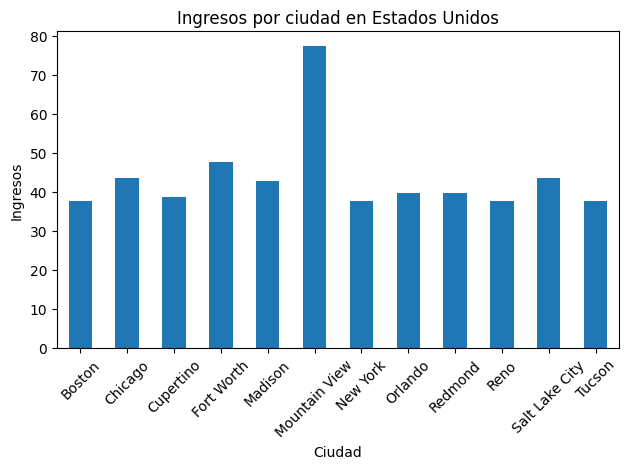

In [167]:
ventasUSA = ventasLimpio[ventasLimpio["BillingCountry"] == "USA"]# Filtramos las ventas realizadas en Estados Unidos

tbUSA = pd.pivot_table(# Calculamos los ingresos por ciudad
    ventasUSA,
    index="BillingCountry",
    columns="BillingCity",
    values="Total",
    aggfunc="sum",
    fill_value=0
).rename_axis(index="País", columns="Ciudad")

display(tbUSA)

# Gráfico de barras
tbUSA.T.plot(# Gráfico de barras
    kind="bar",
    legend=False
)

plt.title("Ingresos por ciudad en Estados Unidos")
plt.xlabel("Ciudad")
plt.ylabel("Ingresos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Hallazgos**
  1. Mountain View obtuvo los mayores ingresos, con 77.24, siendo la ciudad con mayor aporte.
  2. Fuera de Mountain View, la mayoría de las ciudades presentan ingresos entre 37.62 y 43.62, mostrando valores bastante similares entre ellas.

**Método de comprobación**
  1. Se realizó un filtrado de datos para trabajar únicamente con las ventas de Estados Unidos.
  2. Se utilizó una tabla dinámica (pd.pivot_table()) para agrupar las ventas por ciudad y obtener los ingresos totales. Colocando BillingCountry como fila y BillingCity como columnas.
  3. Se utilizó una gráfica de barras para comparar visualmente los ingresos generados por cada ciudad.

**Recomendación de negocio**
  1. Analizar Mountain View para identificar qué clientes están comprando tanto y determinar los posibles factores.


---

**Reporte 3: Ingresos por compañias de clientes**

---

Company,Apple Inc.,Banco do Brasil S.A.,Embraer - Empresa Brasileira de Aeronáutica S.A.,Google Inc.,JetBrains s.r.o.,Microsoft Corporation,Riotur,Rogers Canada,Telus,Woodstock Discos
Total,38.62,37.62,39.62,37.62,40.62,39.62,37.62,38.62,37.62,37.62


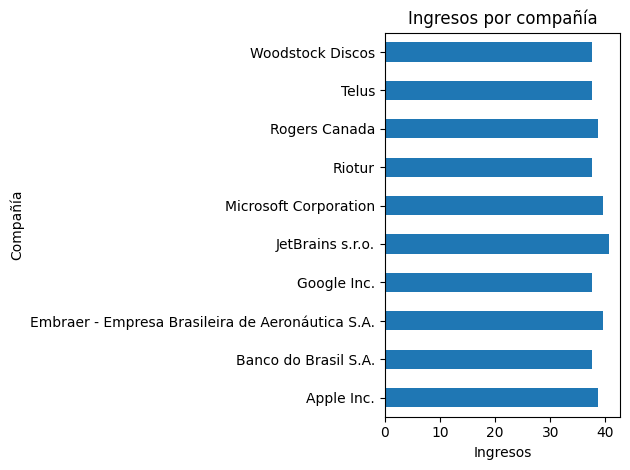

In [168]:
clientesVentas = clientesLimpio.merge(ventasLimpio,on="CustomerId",how="inner")# Unimos los clientes con sus ventas
clientesConCompania = clientesVentas[clientesVentas["Company"] != "Sin compañia"]# Filtramos los clientes que tienen una compañía registrada

# Creamos la tabla pivote con los ingresos en las filas
tablaCompanias = pd.pivot_table(
    clientesConCompania,
    index=None,
    columns="Company",
    values="Total",
    aggfunc="sum"
)

display(tablaCompanias)

# Gráfico de barras
tablaCompanias.T.plot(
    kind="barh",
    legend=False
)

plt.title("Ingresos por compañía")
plt.xlabel("Ingresos")
plt.ylabel("Compañía")
plt.tight_layout()
plt.show()

---

**Reporte 4: Ingresos por mes en 2010**

---

Mes,January,February,March,April,May,June,July,August,September,October,November,December
Año,,,,,,,,,,,,
2010,52.62,46.62,44.62,37.62,37.62,37.62,37.62,37.62,36.63,37.62,37.62,37.62


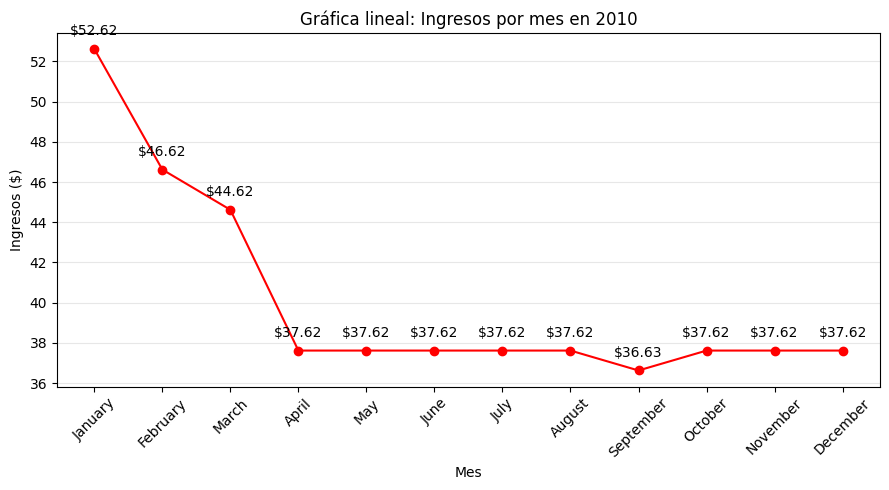

In [169]:
ventasLimpio["InvoiceDate"] = pd.to_datetime(ventasLimpio["InvoiceDate"])#InvoiceDate a formato fecha
ventas2010 = ventasLimpio[ventasLimpio["InvoiceDate"].dt.year == 2010].copy()# Filtro únicamente las ventas del año 2010

ventas2010["Año"] = ventas2010["InvoiceDate"].dt.year# columnas Año y Mes
ventas2010["Mes"] = ventas2010["InvoiceDate"].dt.month_name()

tb2010 = pd.pivot_table(#tabla pivote con los ingresos por mes
    ventas2010,
    index="Año",
    columns="Mes",
    values="Total",
    aggfunc="sum",
    fill_value=0
)
# Ordenar los meses de enero a diciembre
meses = ["January", "February", "March", "April", "May", "June","July", "August", "September", "October", "November", "December"]
tabla2010 = tb2010.reindex(columns=meses)

display(tabla2010)

# Gráfica
plt.figure(figsize=(9, 5))

plt.plot(
    tabla2010.columns,
    tabla2010.iloc[0].values,
    marker="o",
    color="red"
)

for mes, venta in zip(tabla2010.columns, tabla2010.iloc[0].values):
    texto = f"${venta:,.2f}"
    plt.annotate(
        texto,
        (mes, venta),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center"
    )

plt.title("Gráfica lineal: Ingresos por mes en 2010")
plt.xlabel("Mes")
plt.ylabel("Ingresos ($)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

* **Hallazgos**
  1. Enero registró los mayores ingresos del año, con 52.62.
  2. Septiembre presentó el ingreso más bajo, con 36.63.
  3. En general, se observa una disminución de los ingresos durante los primeros meses de 2010, pasando de 52.62 en enero a 37.62 en abril.

* **Método de comprobación**
  1. Se convirtió InvoiceDate al formato de fecha.
  2. Se filtraron únicamente las ventas realizadas durante 2010.
  3. Se utilizó una tabla dinámica (pivot_table) para sumar Total y obtener los ingresos de cada mes.
  4. Se organizó la información cronológicamente de enero a diciembre y se representó mediante una gráfica lineal.

* **Recomendación de negocio**
  1. Revisar qué factores hicieron que los ingresos fueran mayores en enero, febrero y marzo, para identificar comportamientos que puedan repetirse.
  2. Utilizar el comportamiento mensual de 2010 como referencia para planificar promociones o estrategias comerciales en los meses de menores ingresos.